In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
from pathlib import Path
import pandas as pd
import json
from src.config import CHECKPOINT_DIR, DEFAULT_TRAINING_PARAMS_V2, DEFAULT_TRAINING_PARAMS_V3, DEFAULT_TRAINING_PARAMS_V4, DEFAULT_STGCN_PARAMS_V1
from pathlib import Path
import matplotlib.pyplot as plt


In [2]:
def make_title(run_name, config, default_config=DEFAULT_TRAINING_PARAMS_V3):
    title = [run_name]

    for param in config:
        if param in default_config and config[param] != default_config[param]:
            title.append(f"{param}={config[param]}")

    return " | ".join(title)

def get_results(results_path):

    history_path = results_path / "history.csv"
    summary_path = results_path / "summary.csv"
    config_path = results_path / "config.json"

    required_files = [
        history_path,
        summary_path,
        config_path,
    ]

    if not all(path.exists() for path in required_files):
        return None

    history = pd.read_csv(history_path)
    summary = pd.read_csv(summary_path)

    with config_path.open("r", encoding="utf-8") as f:
        config = json.load(f)

    return history, summary, config

def plot_grid_search_results(experiment_root, default_config):

    run_dirs = sorted([d for d in experiment_root.iterdir() if d.is_dir()])
    
    for run_dir in run_dirs:

        results = get_results(run_dir)

        if results is None:
            print(f"Skipping incomplete run: {run_dir.name}")
            continue

        history, summary, config = results

        epochs = range(1, len(history["train_loss"]) + 1)

        title = make_title(run_dir.name, config, default_config=default_config)

        plt.figure(figsize=(12, 5))

        # Loss plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, history["train_loss"], label="Train Loss")
        plt.plot(epochs, history["val_loss"], label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss")
        plt.legend()
        plt.grid(True)

        # Accuracy plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, history["train_acc"], label="Train Acc")
        plt.plot(epochs, history["val_acc"], label="Val Acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy")
        plt.legend()
        plt.grid(True)

        plt.suptitle(title, fontsize=16)
        plt.tight_layout()
        plt.show()

        print(summary['best_val_acc'][0])
        print(config)

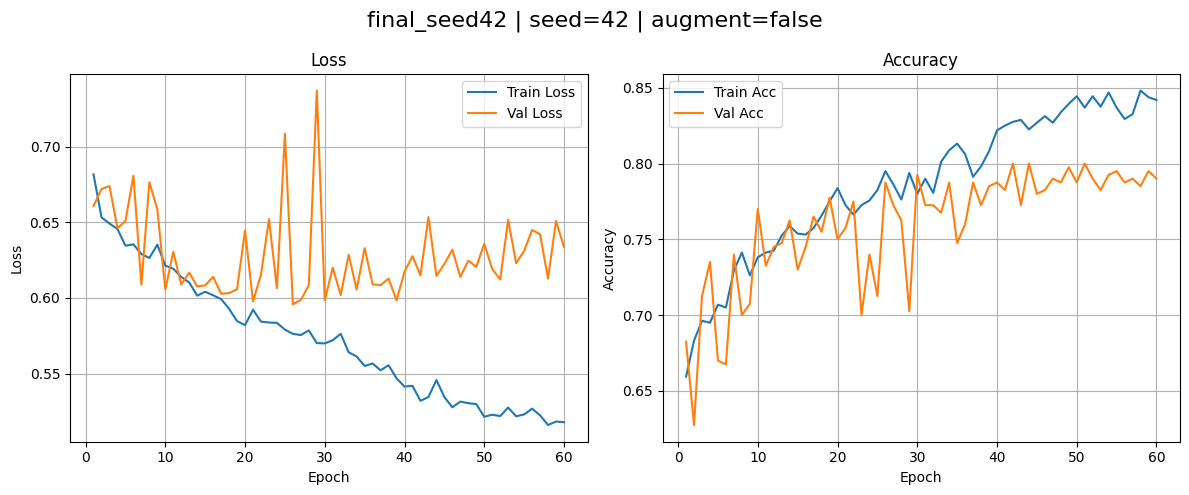

0.8
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': 'false', 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


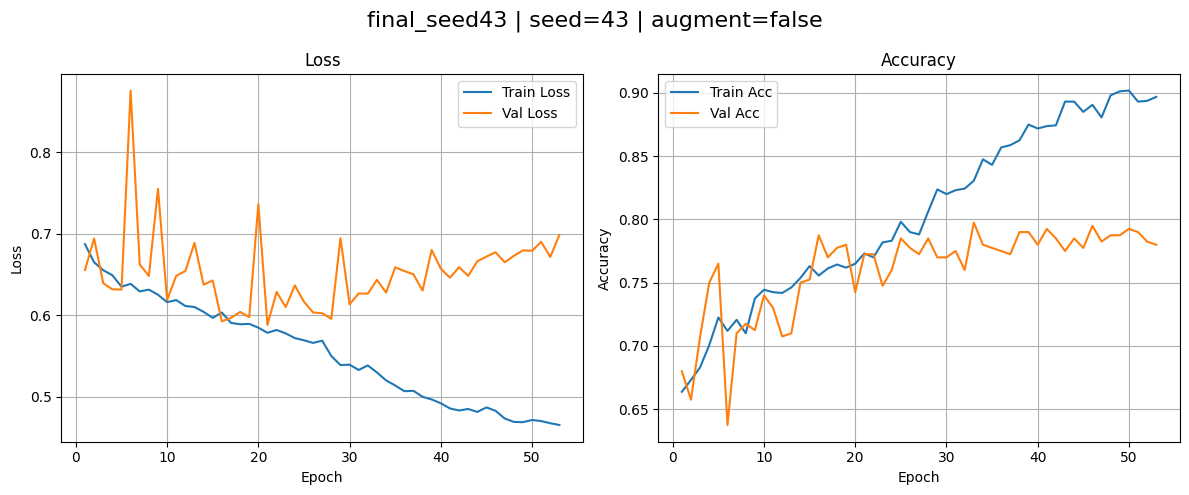

0.7975
{'seed': 43, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': 'false', 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


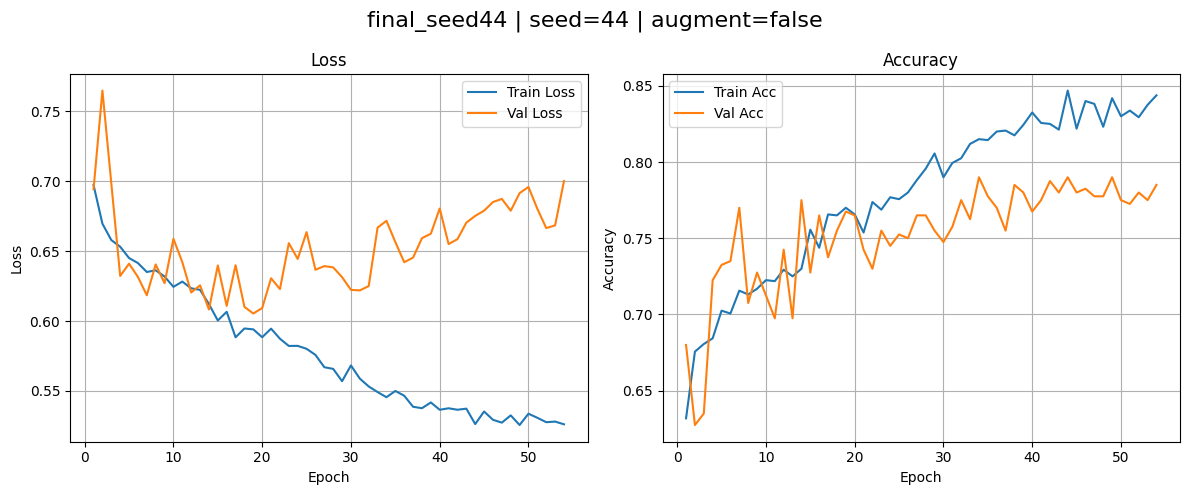

0.79
{'seed': 44, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': 'false', 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


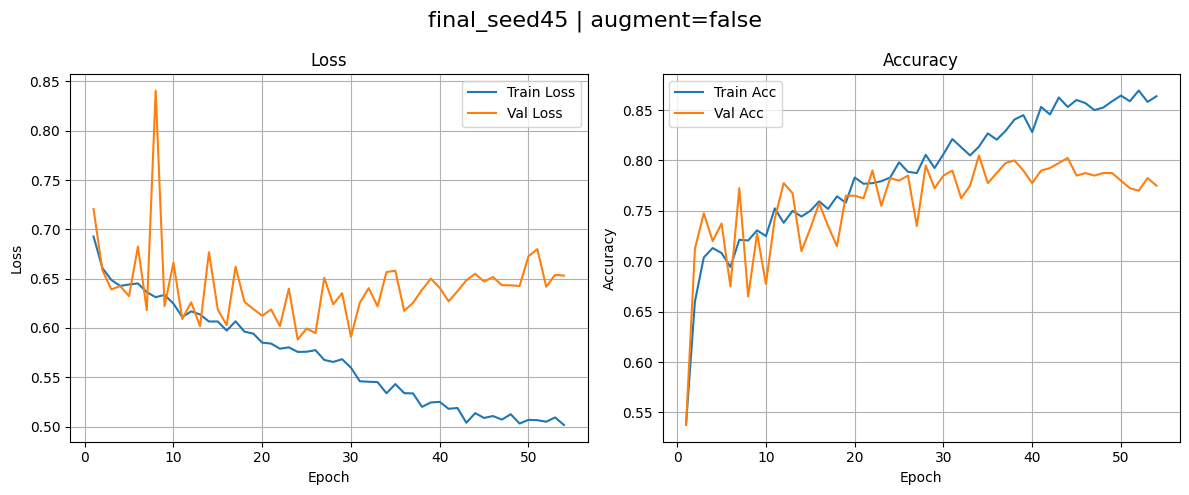

0.805
{'seed': 45, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': 'false', 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


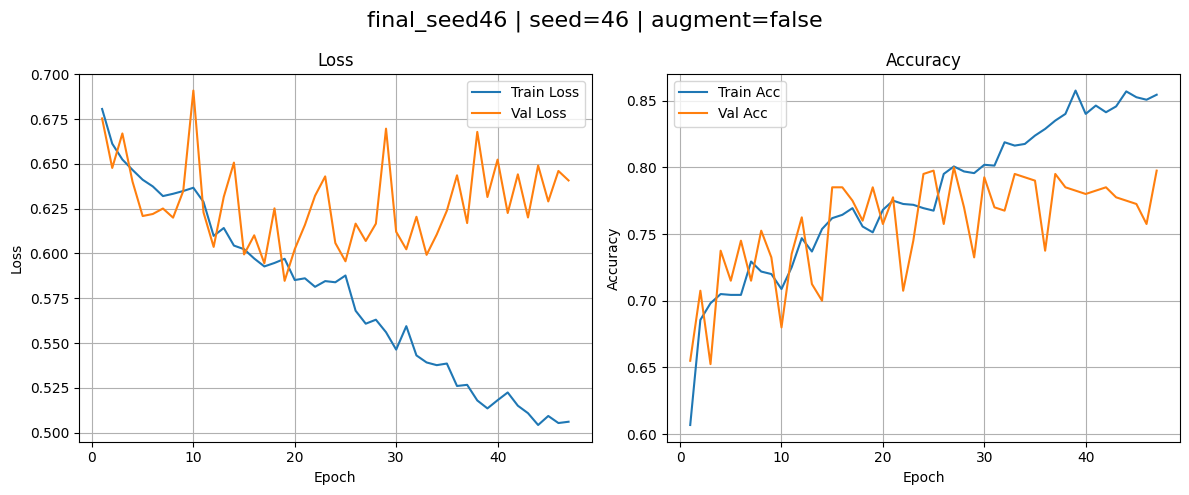

0.8
{'seed': 46, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': 'false', 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


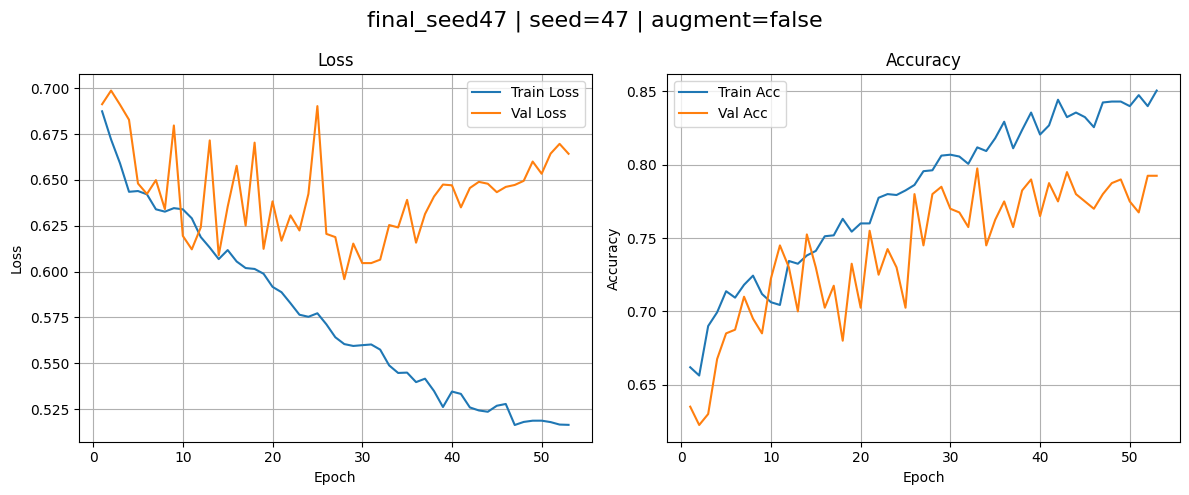

0.7975
{'seed': 47, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': 'false', 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


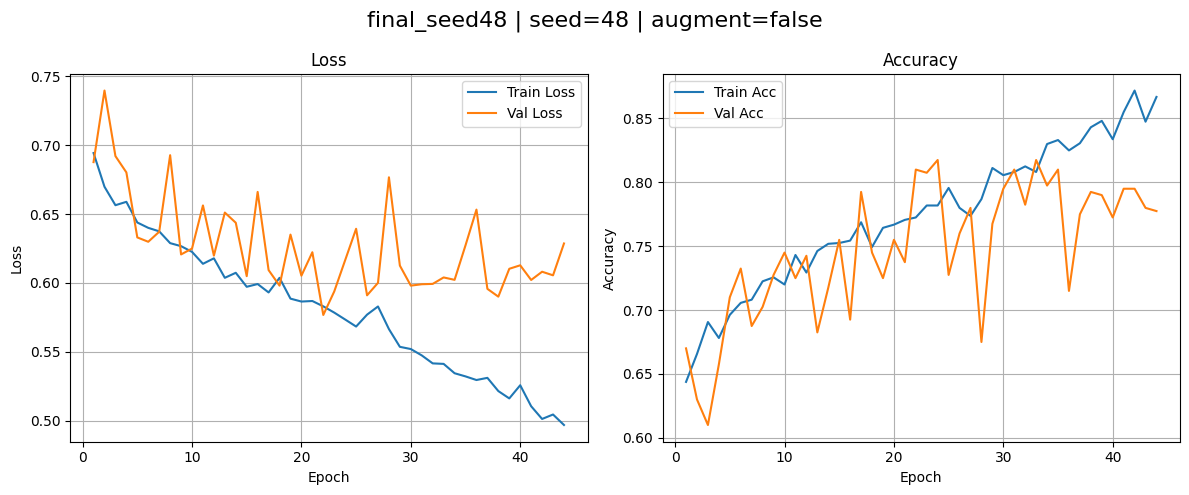

0.8175
{'seed': 48, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': 'false', 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


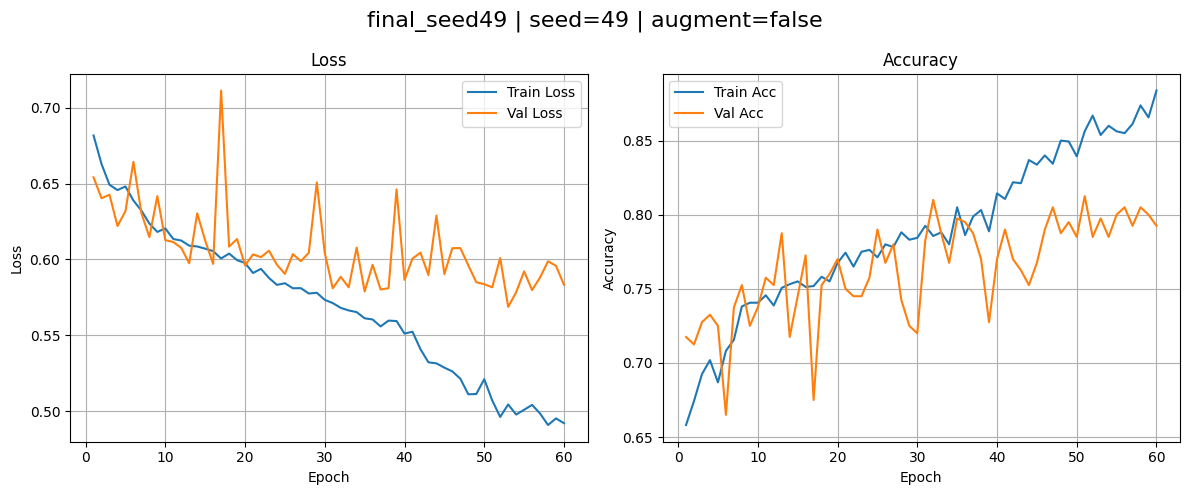

0.8125
{'seed': 49, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': 'false', 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


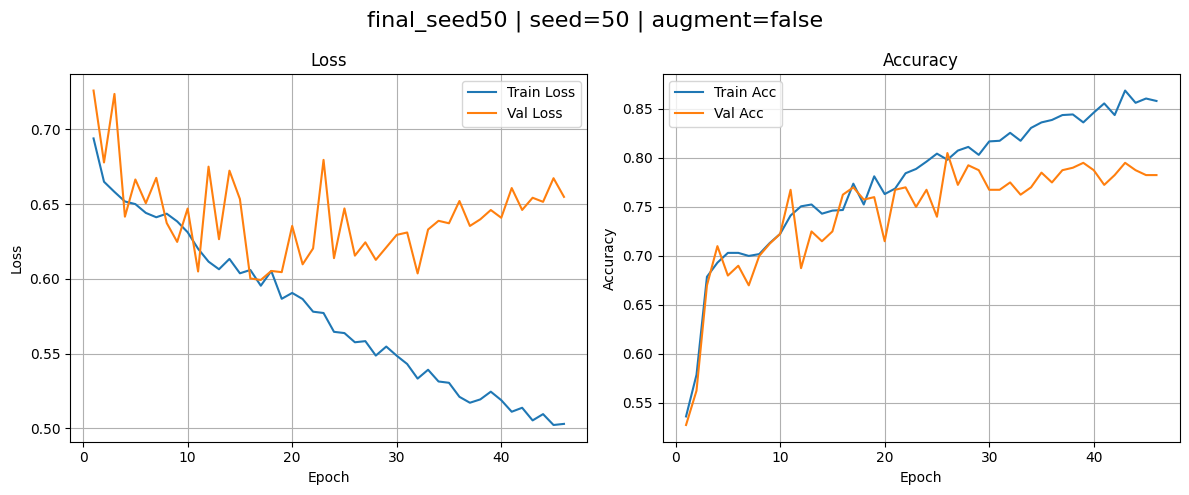

0.805
{'seed': 50, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': 'false', 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


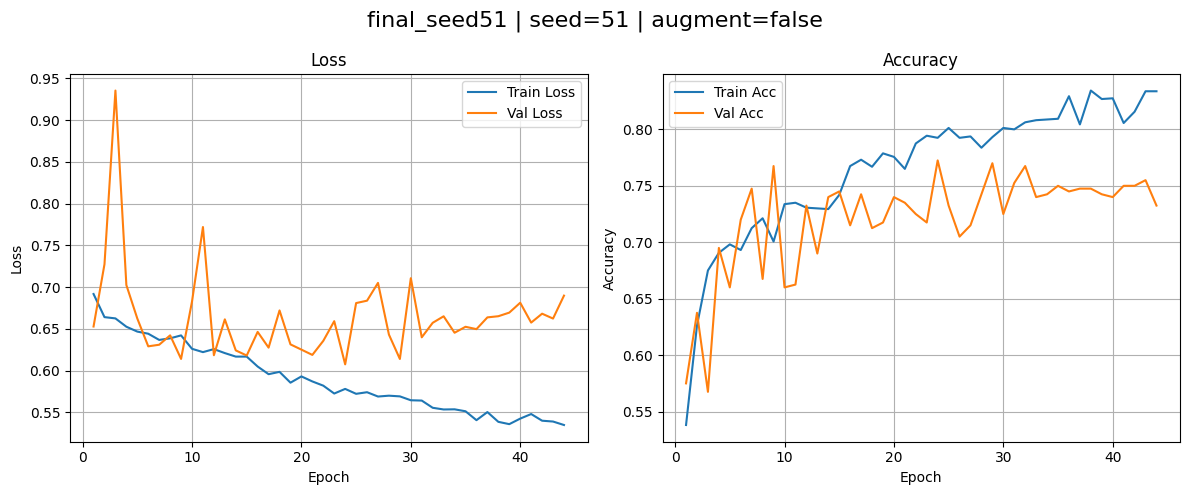

0.7725
{'seed': 51, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': 'false', 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


In [4]:
# stgcn

experiment_root = CHECKPOINT_DIR / "STGCN_V2" / "initial_search"
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "learning_rate_increased_ES"
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "final_test_batch_size"
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "final_test_dropout"
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "final_seed_search"
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "final_seed_search_no_aug"



default_config = DEFAULT_STGCN_PARAMS_V1

plot_grid_search_results(experiment_root, default_config=default_config)

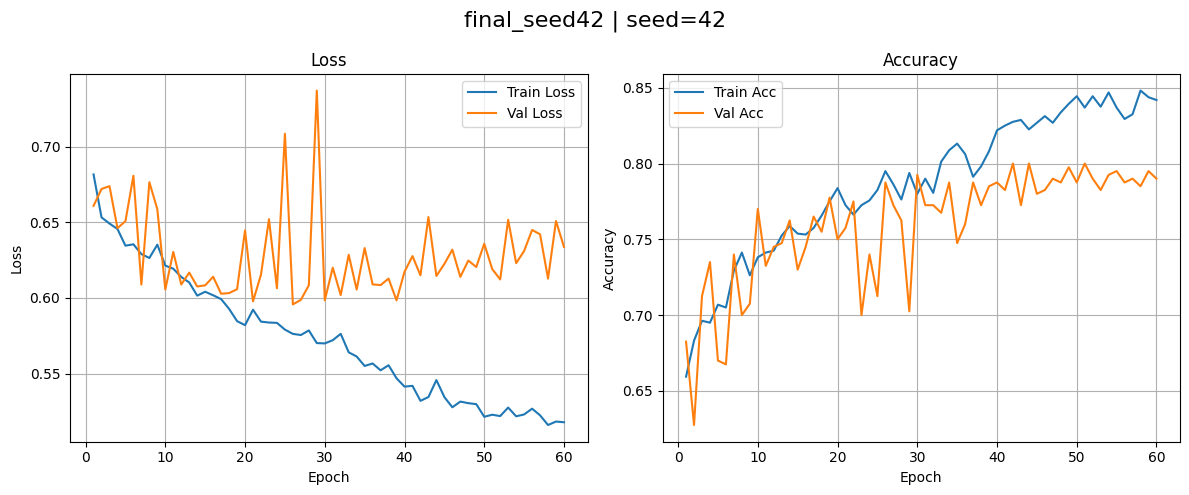

0.8
{'seed': 42, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': True, 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


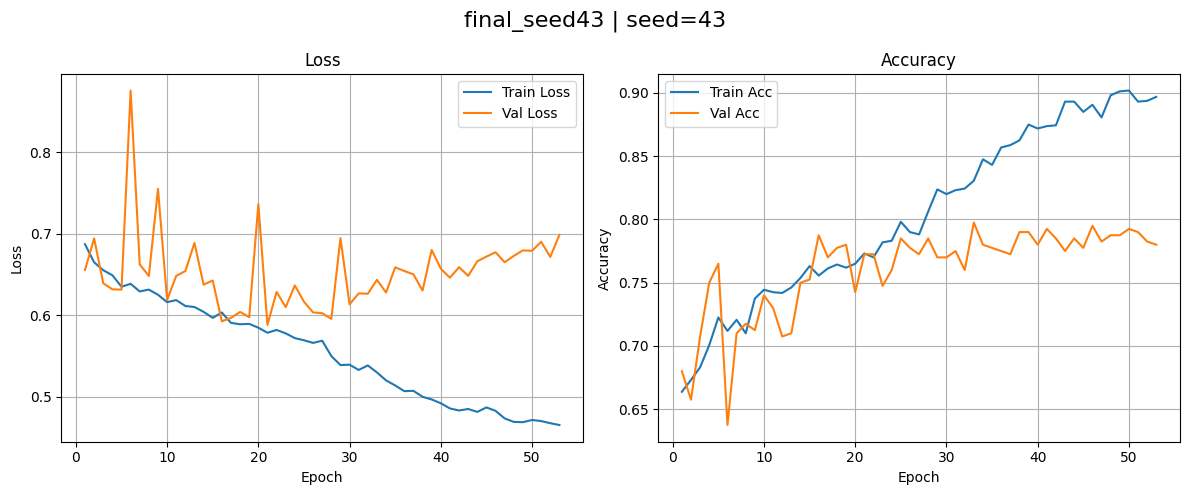

0.7975
{'seed': 43, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': True, 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


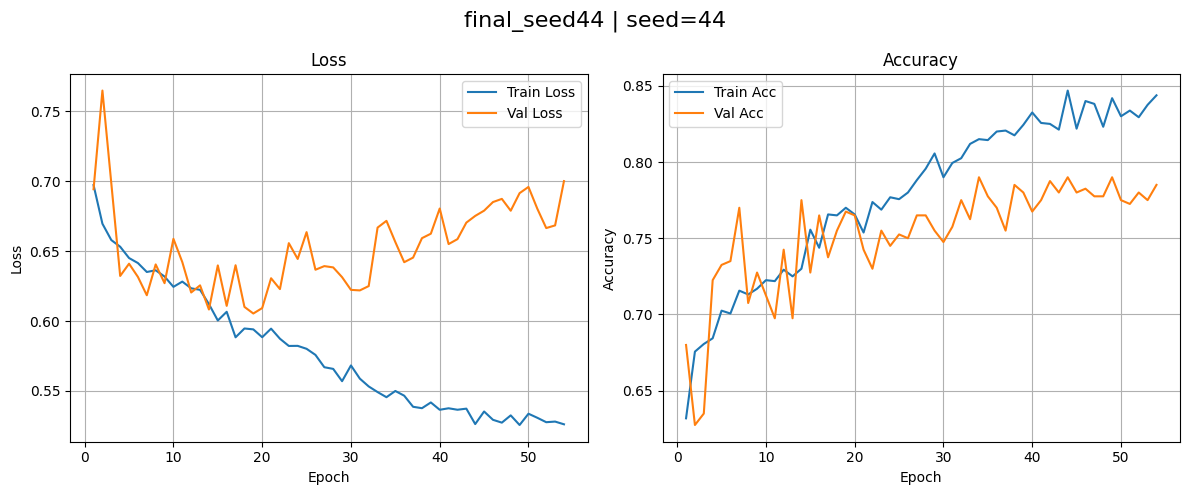

0.79
{'seed': 44, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': True, 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


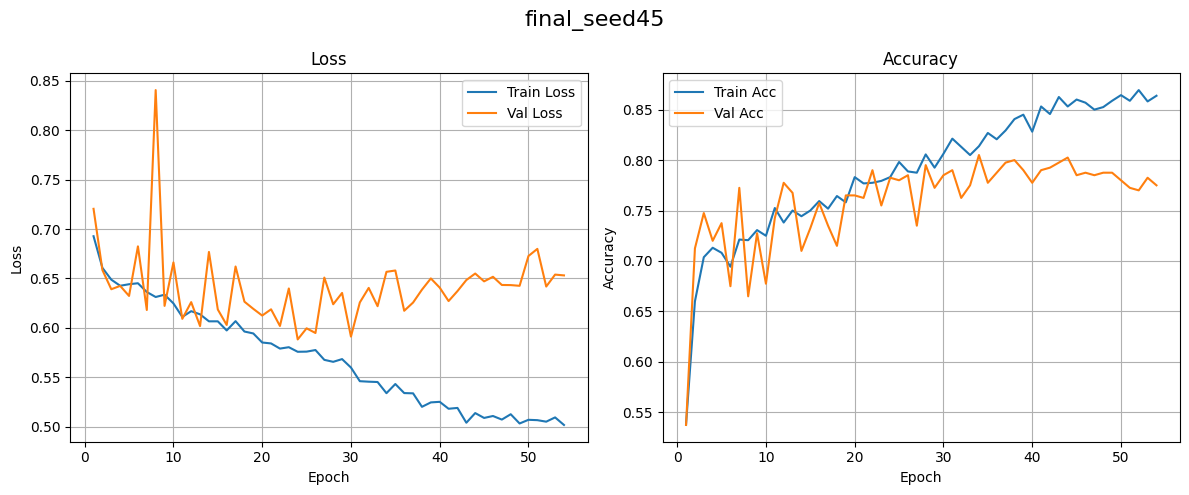

0.805
{'seed': 45, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': True, 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


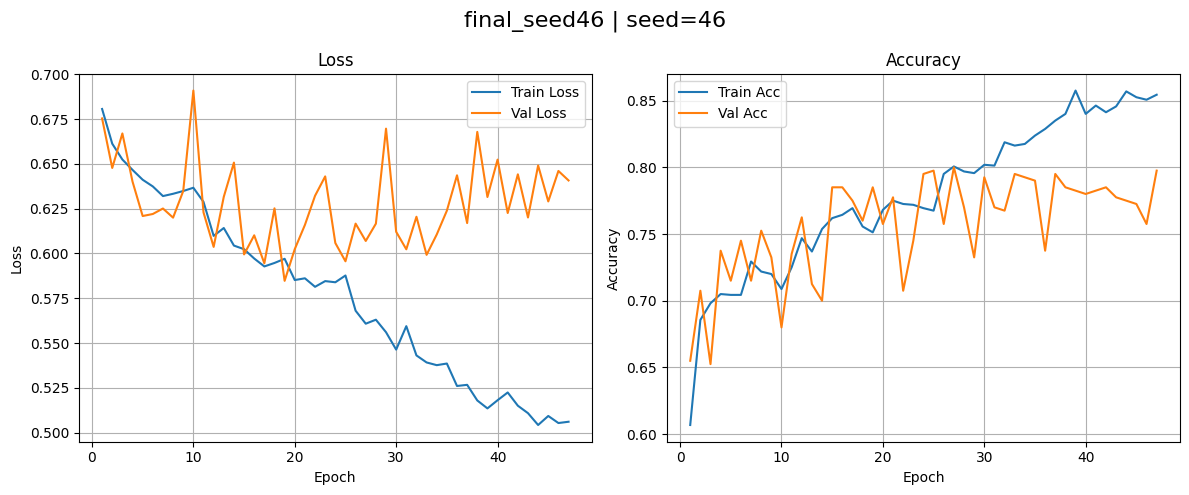

0.8
{'seed': 46, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': True, 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


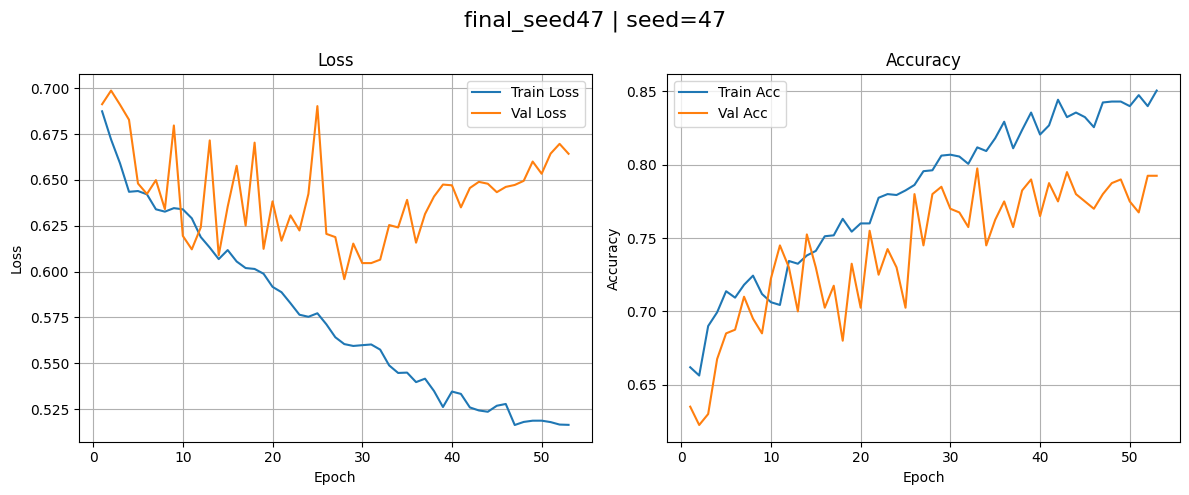

0.7975
{'seed': 47, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': True, 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


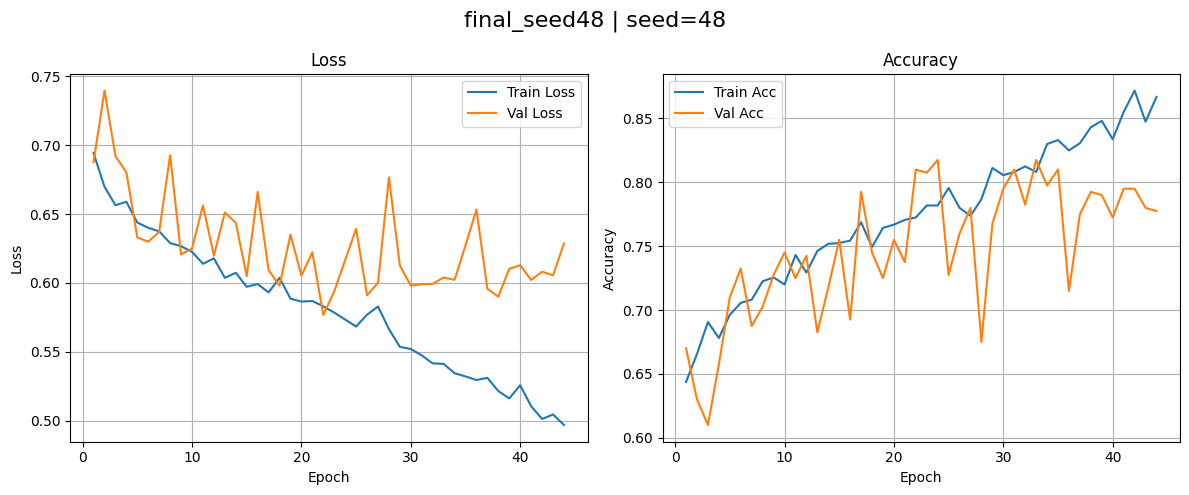

0.8175
{'seed': 48, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': True, 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


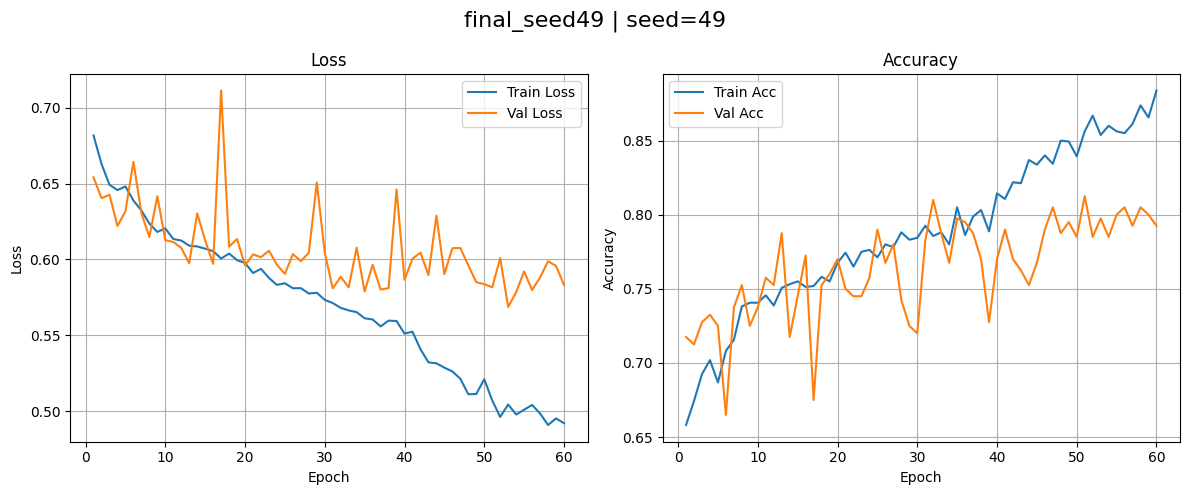

0.8125
{'seed': 49, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': True, 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


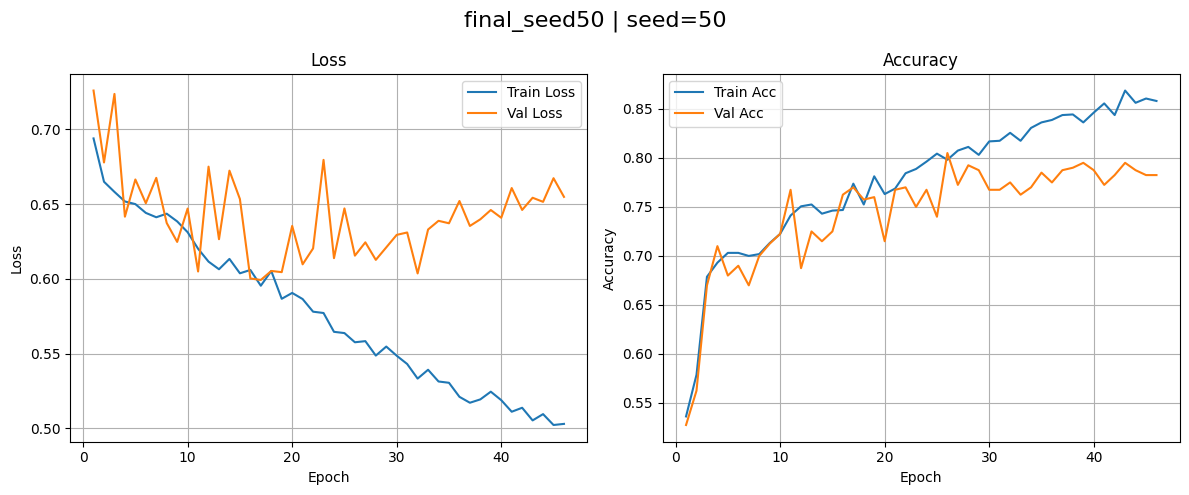

0.805
{'seed': 50, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': True, 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


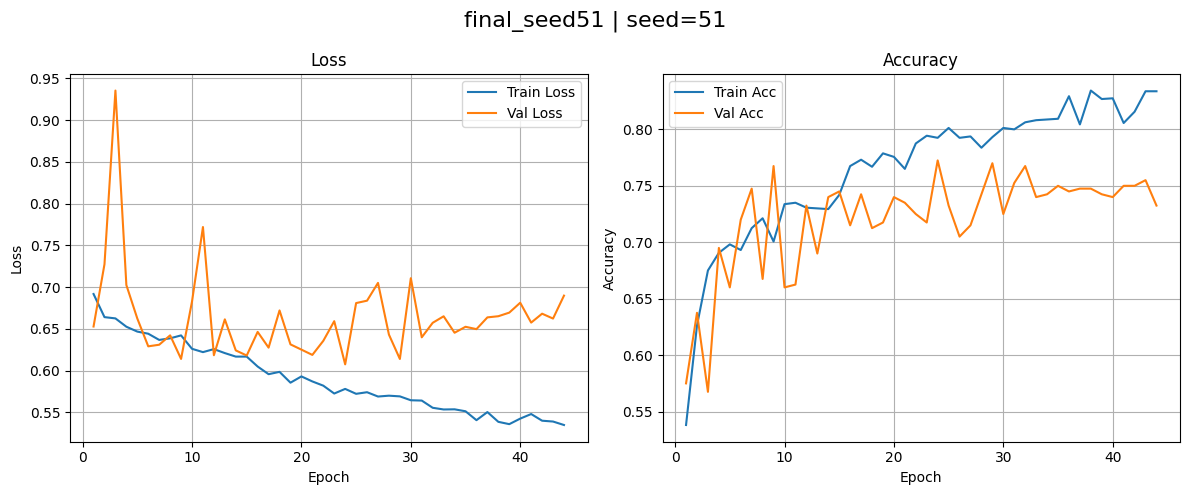

0.7725
{'seed': 51, 'use_gamma_corrected_data': False, 'max_people': 4, 'score_mode': 'total_confidence', 'batch_size': 12, 'augment': True, 'epochs': 60, 'learning_rate': 0.0003, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 20, 'amsgrad': False, 'weight_decay': 5e-05, 'label_smoothing': 0.2, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True, 'people_aggregation': 'masked_mean'}


In [5]:
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "final_seed_search_updated_masked_bn"


default_config = DEFAULT_STGCN_PARAMS_V1

plot_grid_search_results(experiment_root, default_config=default_config)